# <font color="#ec83e6"> Music Genres Clustering Project : </font>

&nbsp;&nbsp;&nbsp;Her insanın müzik zevki farklıdır. Bir kişinin yaşam tarzını, hobilerini veya mesleğini bilerek ne tür müzik sevdiğini belirleyemeyiz. Bu nedenle müzik yayın uygulamalarının bir kişiye müzik önermesi zordur. Ancak bir kişinin günlük olarak ne tür şarkılar dinlediğini biliyorsak, tüm müzik dosyalarında benzerlikler bulabilir ve kişiye benzer müzikler önerebiliriz. İşte tam bu noktada müzik türlerinin kümeleme analizi yani Clustering Projeleri devreye giriyor. Bu projede Spotify'da popüler şarkılardan oluşan bir verimiz mevcut; bu veri seti, her müziğin tüm ses özelliklerini içeren sanatçı ve müzik isimlerini içeriyor. Amacımız ise, ses özelliklerindeki benzerliklere dayanarak müzik türlerini gruplandıran bir model oluşturmaktır. Modelimizi önce geleneksel makine öğrenimi olan Kmeans ile eğitip daha sonrasında da derin öğrenme ile eğitime tabi tutup bu ikisinin sonuçlarını görsel olarak karşılaştırıyor olacağız.<br>
&nbsp;&nbsp;&nbsp;Kümeleme yapmamız gerektiğinden elimizdeki datayı Elbow yani dirsek analizimize göre ideal grup sayısına bölmek olacaktır. Bu hedef baz alınarak silhouette_score üzerinden müzik türleri için ideal grup sayısını belirliyor olacağız.

In [1]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#ec83e6' dur.

#### Veri Sözlüğüm : <br>
**Title:** Şarkıların isimleri ya da albüm isimleri<br>
**Artist:** Şarkının söyleyeni<br>
**Top Genre:** Müziğin türü<br>
**Year:** Şarkının çıktığı yıl<br>
**Beats Per Minute (BPM):** Dakikadaki Vuruş Sayısı<br>
**Energy:** Müziğin enerjisi<br>
**Danceability:** Dans edilebilirlik<br>
**Loudness (dB):** Ses yüksekliği<br>
**Liveness:** Canlılık<br>
**Valence:** Değerlik<br>
**Length (Duration):** Şarkının uzunluğu (süresi)<br>
**Acousticness:** Akustiklik<br>
**Speechiness:** Konuşma yeteneği<br>
**Popularity:** Popülerlik<br>

***Hedef: Müzik türlerininden En Az Kaç Küme Yapabileceğimize Karar Vermek***<br>

<img src="https://cdnpub.egitim.com/egitim_com/public/uploads/content/62987fd8f3e3b6099a90ba9b947431a4b6b24a3c.webp">

In [1]:
import pandas as pd
pd.set_option('display.max_columns',100)

import numpy as np
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import sqlite3

from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from tensorflow.keras import layers, models
import umap

&nbsp;&nbsp;&nbsp;Önce müzik türlerini ve özelliklerini içeren Spotify platformundan alınmış csv dosyamızı çekelim.

In [2]:
df = pd.read_csv("Spotify-2000.csv")

## <font color="#ec83e6"> EDA - Exploratory Data Analysis: </font>

&nbsp;&nbsp;&nbsp;Datamız hakkında bilgi edinmek ile projemize başlıyoruz.

In [5]:
df.head()

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [6]:
df.tail()

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
1989,1990,Heartbreak Hotel,Elvis Presley,adult standards,1958,94,21,70,-12,11,72,128,84,7,63
1990,1991,Hound Dog,Elvis Presley,adult standards,1958,175,76,36,-8,76,95,136,73,6,69
1991,1992,Johnny B. Goode,Chuck Berry,blues rock,1959,168,80,53,-9,31,97,162,74,7,74
1992,1993,Take Five,The Dave Brubeck Quartet,bebop,1959,174,26,45,-13,7,60,324,54,4,65
1993,1994,Blueberry Hill,Fats Domino,adult standards,1959,133,50,49,-10,16,83,148,74,3,56


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Index                   1994 non-null   int64 
 1   Title                   1994 non-null   object
 2   Artist                  1994 non-null   object
 3   Top Genre               1994 non-null   object
 4   Year                    1994 non-null   int64 
 5   Beats Per Minute (BPM)  1994 non-null   int64 
 6   Energy                  1994 non-null   int64 
 7   Danceability            1994 non-null   int64 
 8   Loudness (dB)           1994 non-null   int64 
 9   Liveness                1994 non-null   int64 
 10  Valence                 1994 non-null   int64 
 11  Length (Duration)       1994 non-null   object
 12  Acousticness            1994 non-null   int64 
 13  Speechiness             1994 non-null   int64 
 14  Popularity              1994 non-null   int64 
dtypes: i

In [8]:
df.describe()

,Index,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Acousticness,Speechiness,Popularity
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.00000
mean,997.500000,1992.992979,120.215647,59.679539,53.238215,-9.008526,19.012036,49.408726,28.858074,4.994985,59.52658
std,575.762538,16.116048,28.028096,22.154322,15.351507,3.647876,16.727378,24.858212,29.011986,4.401566,14.35160
min,1.000000,1956.000000,37.000000,3.000000,10.000000,-27.000000,2.000000,3.000000,0.000000,2.000000,11.00000
25%,499.250000,1979.000000,99.000000,42.000000,43.000000,-11.000000,9.000000,29.000000,3.000000,3.000000,49.25000
50%,997.500000,1993.000000,119.000000,61.000000,53.000000,-8.000000,12.000000,47.000000,18.000000,4.000000,62.00000
75%,1495.750000,2007.000000,136.000000,78.000000,64.000000,-6.000000,23.000000,69.750000,50.000000,5.000000,71.00000
max,1994.000000,2019.000000,206.000000,100.000000,96.000000,-2.000000,99.000000,99.000000,99.000000,55.000000,100.00000


In [9]:
df.isnull().sum() 

Index                     0
Title                     0
Artist                    0
Top Genre                 0
Year                      0
Beats Per Minute (BPM)    0
Energy                    0
Danceability              0
Loudness (dB)             0
Liveness                  0
Valence                   0
Length (Duration)         0
Acousticness              0
Speechiness               0
Popularity                0
dtype: int64

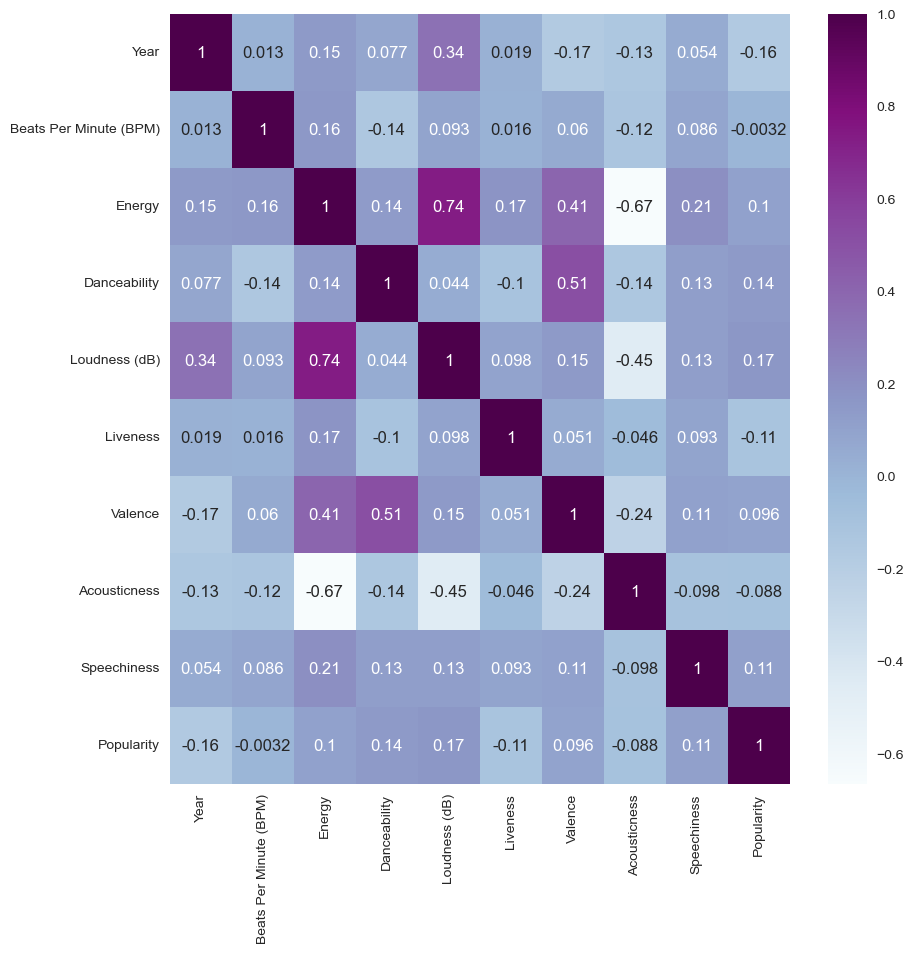

In [58]:
plt.figure(figsize=(10,10)) 
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="BuPu"); # annot rakamları gostermesi icin kare icindeki

In [11]:
df.shape

(1994, 15)

&nbsp;&nbsp;&nbsp;Son olarak sütun ve satır sayımızı da gördükten sonra sütunlar üzerinde düzeltmeler yapmak adına işlemlere başlayalım. 

## <font color="#ec83e6"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp;Yukarıdaki keşif bölümümüzde grdüğümüz üzere 15 sütunumuz var ve hepsi gerekli değil. Bu yüzden ilk olarak 'İndex' sütununu atmak ile çalışmaya başlıyoruz çünkü o sütun sadece index sayısını belirtiyor ve gereksiz bizim için.

In [3]:
df = df.drop("Index", axis=1)

In [13]:
df.head()

,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


&nbsp;&nbsp;&nbsp;Şimdi bu bir Clustering projesi olduğundan sütunların birbirine olan benzerliğine bir göz atalım. Burada sadece rakamsal olan sütunların benzerliğine bakıyoruz.

In [14]:
df.corr(numeric_only=True)

,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Acousticness,Speechiness,Popularity
Year,1.000000,0.012570,0.147235,0.077493,0.343764,0.019017,-0.166163,-0.132946,0.054097,-0.158962
Beats Per Minute (BPM),0.012570,1.000000,0.156644,-0.140602,0.092927,0.016256,0.059653,-0.122472,0.085598,-0.003181
Energy,0.147235,0.156644,1.000000,0.139616,0.735711,0.174118,0.405175,-0.665156,0.205865,0.103393
Danceability,0.077493,-0.140602,0.139616,1.000000,0.044235,-0.103063,0.514564,-0.135769,0.125229,0.144344
Loudness (dB),0.343764,0.092927,0.735711,0.044235,1.000000,0.098257,0.147041,-0.451635,0.125090,0.165527
Liveness,0.019017,0.016256,0.174118,-0.103063,0.098257,1.000000,0.050667,-0.046206,0.092594,-0.111978
Valence,-0.166163,0.059653,0.405175,0.514564,0.147041,0.050667,1.000000,-0.239729,0.107102,0.095911
Acousticness,-0.132946,-0.122472,-0.665156,-0.135769,-0.451635,-0.046206,-0.239729,1.000000,-0.098256,-0.087604
Speechiness,0.054097,0.085598,0.205865,0.125229,0.125090,0.092594,0.107102,-0.098256,1.000000,0.111689
Popularity,-0.158962,-0.003181,0.103393,0.144344,0.165527,-0.111978,0.095911,-0.087604,0.111689,1.000000


&nbsp;&nbsp;&nbsp;Şimdi datamızda 'Popularity' olan popülerlik sütunun dağılımına görsel olarak bir bakalım.

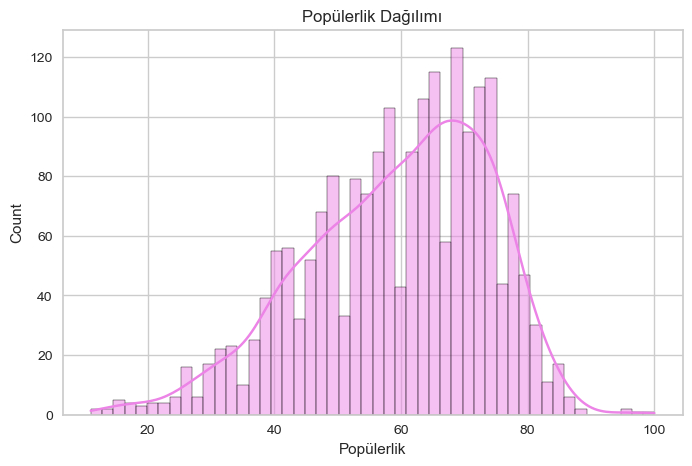

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Popularity'], color="#ec83e6", kde=True, bins=50)  
plt.xlabel('Popülerlik')
plt.title('Popülerlik Dağılımı')
plt.show()

&nbsp;&nbsp;&nbsp;Biraz sütunlarımızı incelediğimizde görüyoruz ki bir müziğin türünü belirleyen bir model oluşturmak için albüm ya da şarkı ismine ('Title') ya da yazar ismine ('Artist') ihtiyaç duymayız. Aynı şekilde bir şarkının uzunluğunu tutan 'Length (Duration)' sütununa ya da çıktığı yılı tutan 'Year' sütununun bizim projemize bir yararı yok bu incelemede. Bu sebeple işimize çok da yaramaz dediğimiz sütunları da verisetimizden atıyoruz.

In [4]:
df2 = df.drop(['Title','Artist','Length (Duration)','Year','Popularity','Top Genre'], axis=1)

In [17]:
df2.head()

,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Acousticness,Speechiness
0,157,30,53,-14,11,68,94,3
1,135,79,50,-11,17,81,17,7
2,168,69,66,-9,7,52,2,17
3,173,96,43,-4,3,37,0,4
4,106,82,58,-5,10,87,1,3


In [18]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Beats Per Minute (BPM)  1994 non-null   int64
 1   Energy                  1994 non-null   int64
 2   Danceability            1994 non-null   int64
 3   Loudness (dB)           1994 non-null   int64
 4   Liveness                1994 non-null   int64
 5   Valence                 1994 non-null   int64
 6   Acousticness            1994 non-null   int64
 7   Speechiness             1994 non-null   int64
dtypes: int64(8)
memory usage: 124.8 KB


&nbsp;&nbsp;&nbsp;Gerekli sütunları tuttuktan sonra, veri setimizi hazırlamış olduk ve artık modelimizi Clustering projelerinde geleneksel makine öğrenimi olan Kmeans ile eğitmeye başlayabiliriz.

## <font color="#ec83e6"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp;İlk olarak rastgele 3 sınıf belirleyelim. Daha sonrasında datamızın benzerlik oranına göre ideal sınıf sayısı belirlendiğinde o sınıf sayısı ile modelimizi tekrra eğitip görselleştireceğiz.

In [59]:
model=KMeans(3) 

In [60]:
model=model.fit(df2)

In [61]:
tahmin=model.predict(df2)

In [62]:
silhouette_score(df2,tahmin)

np.float64(0.21387330534324467)

&nbsp;&nbsp;&nbsp;Tahmin oranımız biraz düşük çıktı belli ki veri setimizin benzerlik oranı düşük, fakat bu oranı illa ki sütunlar ile oynayarak düzeltebiliriz muhtemelen.

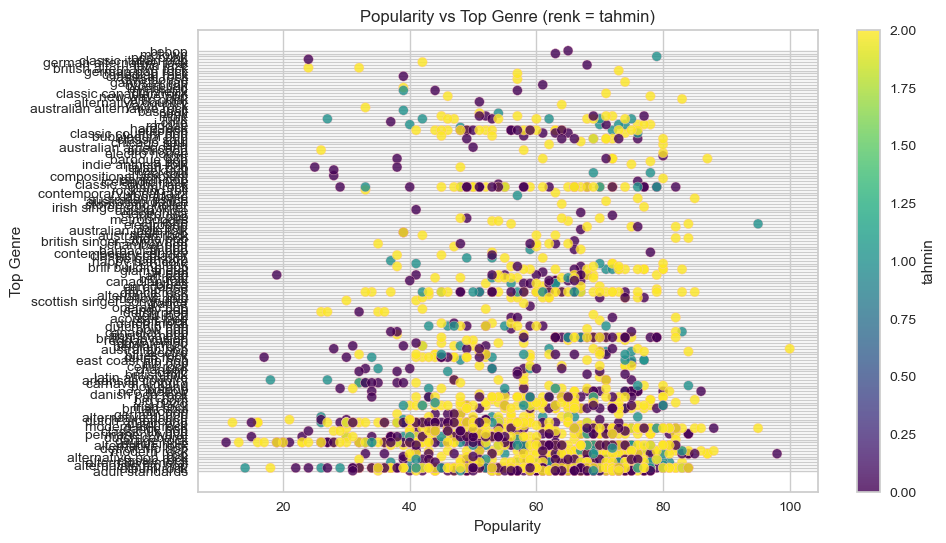

In [63]:
plt.figure(figsize=(10,6))
sc = plt.scatter(df['Popularity'], df['Top Genre'], c=tahmin, cmap='viridis', s=50, alpha=0.8, edgecolor='pink')
plt.colorbar(sc, label='tahmin')  
plt.xlabel('Popularity')
plt.ylabel('Top Genre')
plt.title('Popularity vs Top Genre (renk = tahmin)')
plt.show()

&nbsp;&nbsp;&nbsp;Şimdi de inertia'ya yani datamızın sınıflandırmaya tabi iken tekrar ettiği noktaya bakalım.

In [28]:
#wcss= within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(df2)
    tahmin=model.predict(df2)
    ss1=silhouette_score(df2,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.2826641225370893
0.2319002525172512
0.22166754682972079
0.20775362815348808
0.20639709637091672
0.20460685104412993
0.20770222958765847
0.18754086058644295


&nbsp;&nbsp;&nbsp;Yukarıdaki kodlara göre datamızın tekrara düşen noktası 4. adım olduğuna göre ideal kümeleme sayısı 4 gibi görünüyor. Bu durumda görsel olarak da inceleyerek netleştirelim durumu.

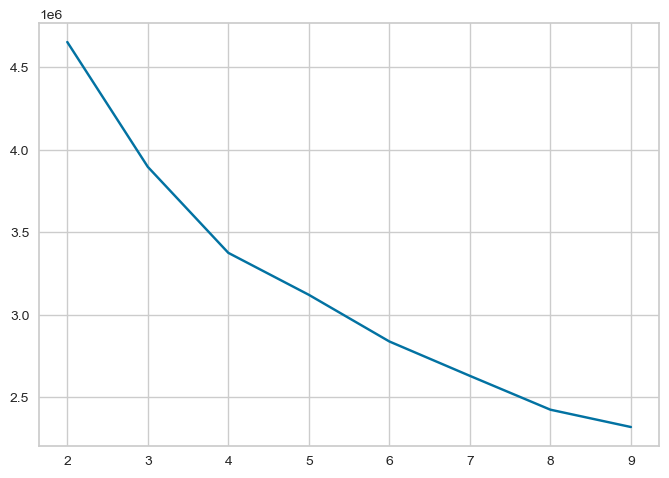

In [64]:
plt.plot(range(2,10),wcss);

&nbsp;&nbsp;&nbsp;Yukarıdaki grafikte görünen o ki 4 ideal grup sayısını veriyor ve kırılma noktası 4 gibi görünüyor. Bu durumda daha detaylı çizime sahip olan başka bir grafikten de yardım alalım emin olmak adına.

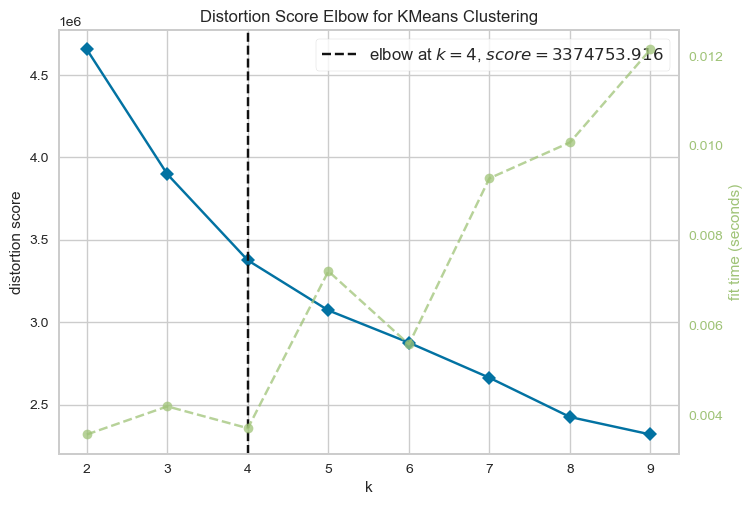

In [31]:
vis=KElbowVisualizer(KMeans(),k=(2,10))  # Elbow'a göre ideal grup sayısı 4 mus. Bu durumda datamızı 4 gruba ayıracagiz
vis.fit(df2)
vis.show();

&nbsp;&nbsp;&nbsp;Madem kırılma noktası 4 olarak daha ideal çıkıyor, bu durumda modelimizi 4 kümeye ayırması adına tekrar modelleyelim.

In [5]:
model2=KMeans(4) 

In [6]:
model2=model2.fit(df2)

In [7]:
tahmin2=model2.predict(df2)

In [8]:
silhouette_score(df2,tahmin2)

np.float64(0.20729112244205572)

In [10]:
from joblib import dump
from sklearn.cluster import KMeans

dump(model2, "music_genres_clustering.joblib")

['music_genres_clustering.joblib']

&nbsp;&nbsp;&nbsp;Datamızı **Dendrogram** yani hiyerarşik kümeleme ile de görselleştirelim. Bu yöntem sonuçlarımızı ağaç biçiminde görselleştirmemize yardımcı olan bir diyagramdır.

In [37]:
data=linkage(df2,method='ward',metric='euclidean')

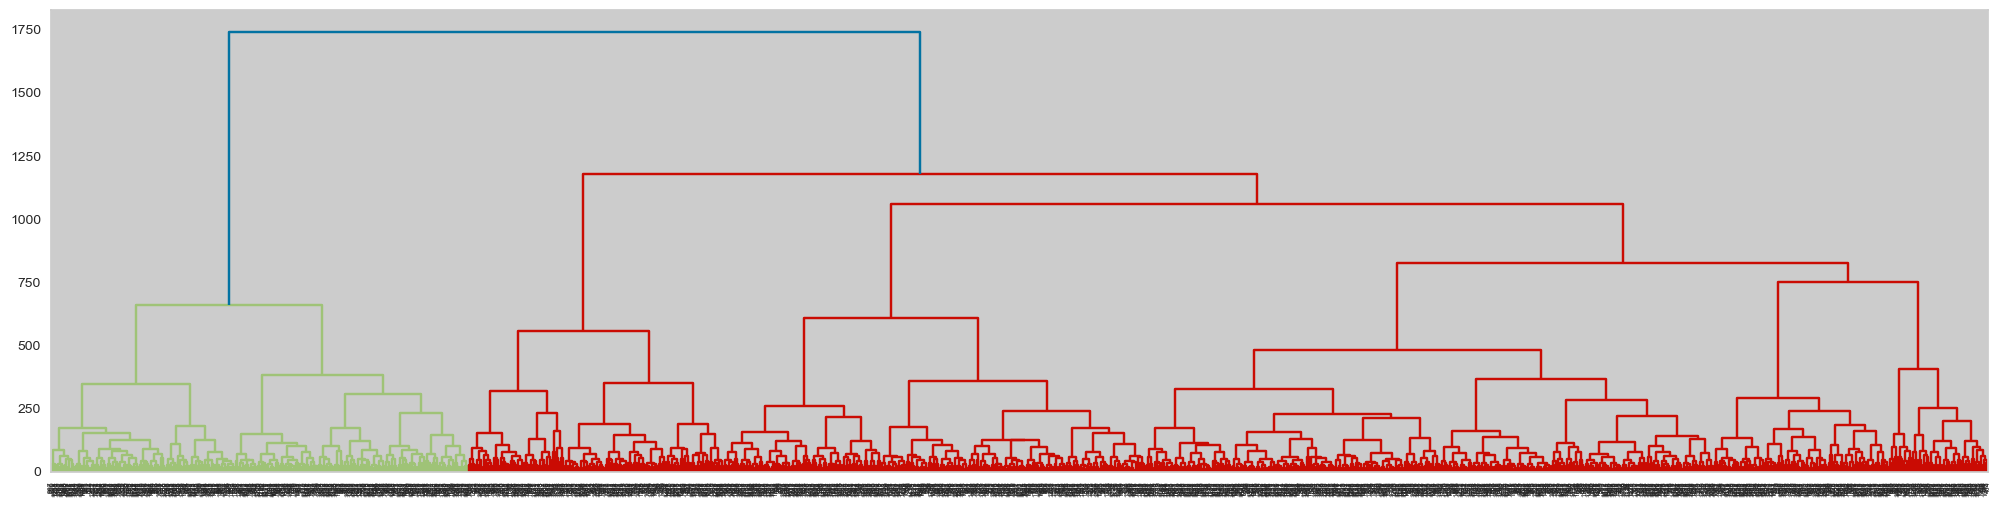

In [38]:
plt.figure(figsize=(25,6))
dendrogram(data);

&nbsp;&nbsp;&nbsp;Burada görüldüğü üzere görselimiz çok fazla sayısal değer olduğu için biraz yoğun oldu, bu sebeple bunu biraz sadeleştirecek bir hale indirgeyelim. 

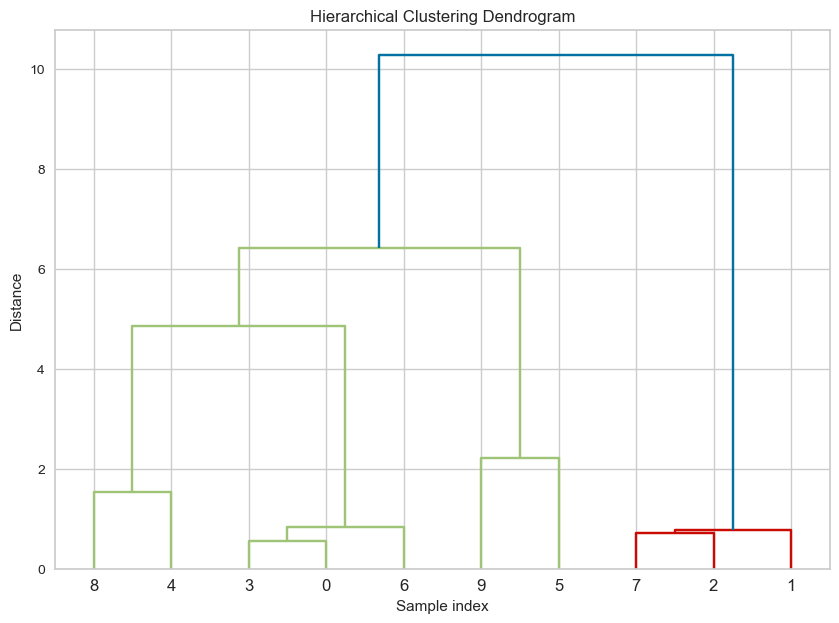

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=4, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

&nbsp;&nbsp;&nbsp;Bir de durumu DBSCAN diye adlandırılan yoğunluk tabanlı bir kümeleme algoritması olan kümeleme yönteminde görelim.

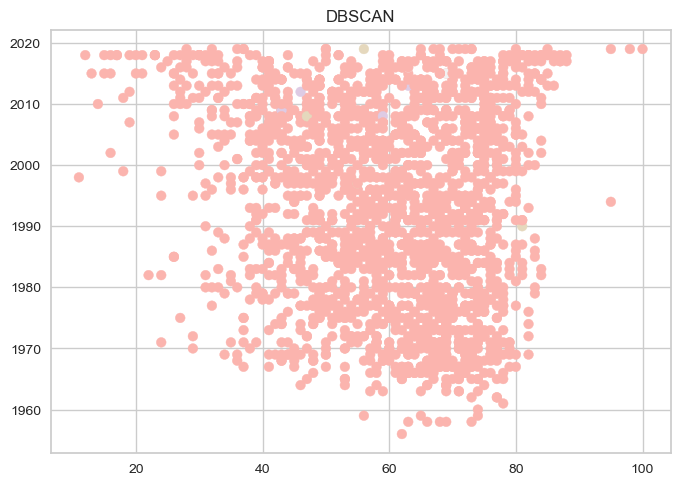

In [44]:
db=DBSCAN(min_samples=4)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(df2)
y=db.fit_predict(x2)
plt.title("DBSCAN")
plt.scatter(df['Popularity'],df['Year'],c=y,cmap='Pastel1');

&nbsp;&nbsp;&nbsp;Son olarak da AgglomerativeClustering (agglomeratif hiyerarşik kümeleme), hiyerarşik kümeleme yöntemlerinin “bottom-up” (aşağıdan yukarı) yaklaşımı olan yöntem ile görelim. 

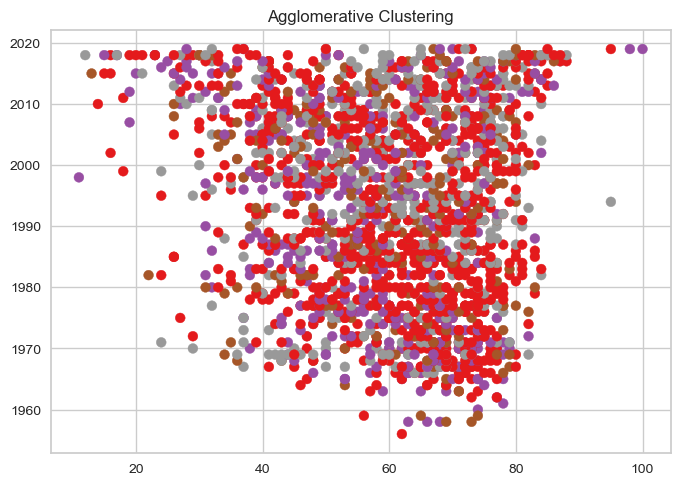

In [50]:
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(df2)

# Plot the results
plt.scatter(df['Popularity'],df['Year'], c=y_agg, s=50, cmap='Set1')
plt.title("Agglomerative Clustering")
plt.show()

&nbsp;&nbsp;&nbsp;Şimdi ise datamızı **Derin Öğrenme** ile eğitip sonuçları inceleyelim. Ama bundan önce datamızı Scale etmemiz gerekiyor.

In [51]:
df2 = StandardScaler().fit_transform(df2)

In [52]:
# autoencoder
input_dim = df2.shape[1]
encoding_dim = 10

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)
encoder = models.Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(df2, df2, epochs=50, batch_size=32, validation_split=0.1)

# latent temsili al ve k-means uygula
Z = encoder.predict(df2)
kmeans = KMeans(n_clusters=4, random_state=42).fit(Z)
labels = kmeans.labels_

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7940 - val_loss: 0.5598
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3180 - val_loss: 0.2274
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1336 - val_loss: 0.1170
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0611 - val_loss: 0.0496
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0342 - val_loss: 0.0357
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0262 - val_loss: 0.0269
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0202 - val_loss: 0.0210
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0162 - val_loss: 0.0174
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0127 - val_loss: 0.0151
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0108 - val_loss: 0.0125
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0095 - val_loss: 0.0117
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084 - val_lo

&nbsp;&nbsp;&nbsp;Ve sonucu görselleştirelim.

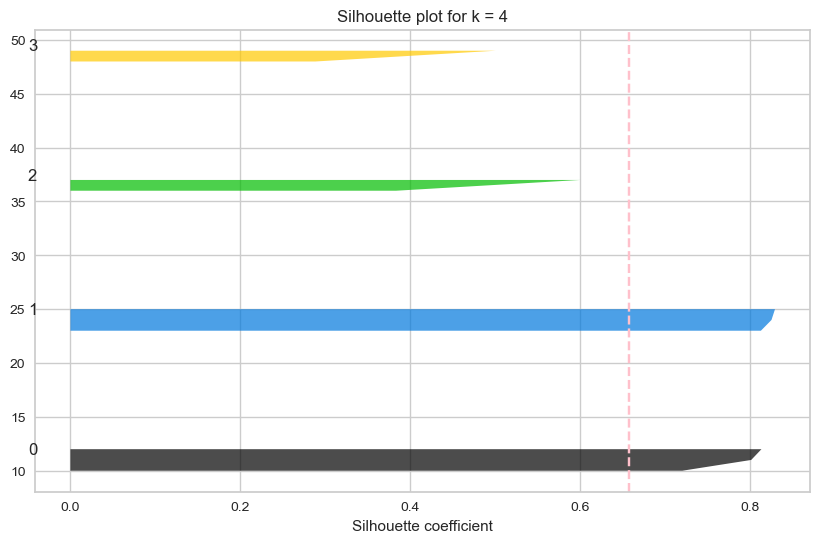

In [53]:
from sklearn.metrics import silhouette_samples
k = 4  # örnek: seçtiğin k
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
labels = kmeans.labels_
sil_vals = silhouette_samples(X, labels)

plt.figure(figsize=(10,6))
y_lower = 10
for i in range(k):
    ith_sil_vals = sil_vals[labels == i]
    ith_sil_vals.sort()
    size_cluster_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.nipy_spectral(float(i) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # boşluk

plt.axvline(x=sil_vals.mean(), color="pink", linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.title(f"Silhouette plot for k = {k}")
plt.show()

&nbsp;&nbsp;&nbsp;Derin öğrenme ile modeli eğitince de ideal sınıfa 4 küme verdik ve yukarıdaki gibi görselleştirdik. Ama daha net başka bir görsel ile destekleyelim sonucumuzu.

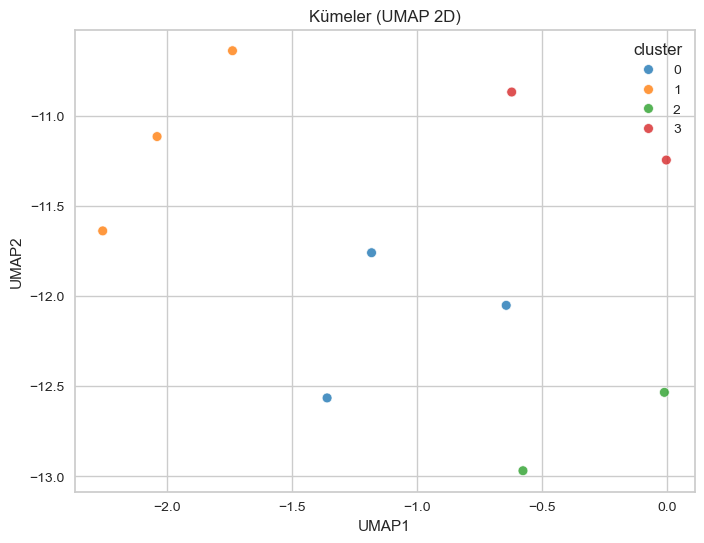

In [56]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels, palette='tab10', s=50, alpha=0.8)
plt.title('Kümeler (UMAP 2D)')
plt.xlabel('UMAP1'); plt.ylabel('UMAP2')
plt.legend(title='cluster')
plt.show()

**Conclusion:** &nbsp;&nbsp;Sonuç olarak; bu projede bazı şarkıları müziğin özelliklerine göre ideal küme sayısını belirleyerek gruplandırmış olduk. Bizim datamız için ideal küme sayısı modelimizin tahmini üzerinden 4 geldi. Bu durumda bu müzikler ideal olarak 4 farklı tür adı altında  gruplandırılabilir diyebiliriz. Silhouette_score yani datamızın benzerlik oranı yaklaşık: 0.2327 çıktı. Düşük bir benzerlik oranı olsa bile en ideal küme sayısı 4 diyebiliyoruz. Tabii sütunların çoğaltılması durumunda benzerlik oranı yukarılara da çekilebilir tahminimiz. <br>
&nbsp;&nbsp;&nbsp;Yapılan bu model Clustering'i içerdiği için onun testleri ile gerçeklestirildi. Sonuçlar dendrogram haritaları üzerinde hiyerarşik olarak gösterildi. Ayrıyeten AgglomerativeClustering ile datanın kümelenme biçimine bakıldı. Son olarak da DBSCAN üzerinden datanın yoğunluğunun durumu hakkında da görsel oluşturuldu.<br>
&nbsp;&nbsp;&nbsp;Yine datamız Derin Öğrenme ile de eğitilip görselleştirdi.

Ve kapanış..